In [ ]:
#Karthick N
#24BAD055
#importing librairies
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

In [ ]:
#Loading the dataset
df = pd.read_csv("fraud_smote.csv")
print(df.head())

    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0


In [ ]:
# Checking class distribution
print(df["Fraud"].value_counts())

Fraud
0    110
1     10
Name: count, dtype: int64


In [ ]:
# Splitting the dataset into features and target variable
X = df.drop("Fraud", axis=1)
y = df["Fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
#Random classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_before = rf.predict(X_test)

print("Before SMOTE Accuracy:", accuracy_score(y_test, y_pred_before))
print(classification_report(y_test, y_pred_before))

Before SMOTE Accuracy: 0.9444444444444444
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        34
           1       0.00      0.00      0.00         2

    accuracy                           0.94        36
   macro avg       0.47      0.50      0.49        36
weighted avg       0.89      0.94      0.92        36



c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
#Using SMOTE Techniques for class imbalance
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(y_train_res.value_counts())

Fraud
0    76
1    76
Name: count, dtype: int64


In [ ]:
# Training the model after SMOTE
rf2 = RandomForestClassifier(random_state=42)
rf2.fit(X_train_res, y_train_res)

y_pred_after = rf2.predict(X_test)

print("After SMOTE Accuracy:", accuracy_score(y_test, y_pred_after))
print(classification_report(y_test, y_pred_after))

After SMOTE Accuracy: 0.8055555555555556
              precision    recall  f1-score   support

           0       0.97      0.82      0.89        34
           1       0.14      0.50      0.22         2

    accuracy                           0.81        36
   macro avg       0.55      0.66      0.56        36
weighted avg       0.92      0.81      0.85        36



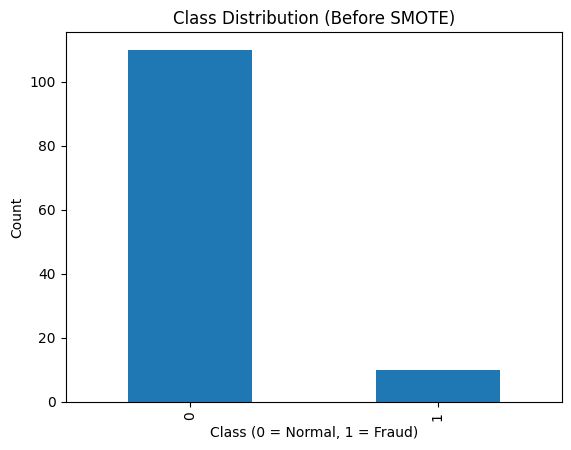

In [27]:
#Visualization
plt.figure()
df["Fraud"].value_counts().plot(kind="bar")
plt.title("Class Distribution (Before SMOTE)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

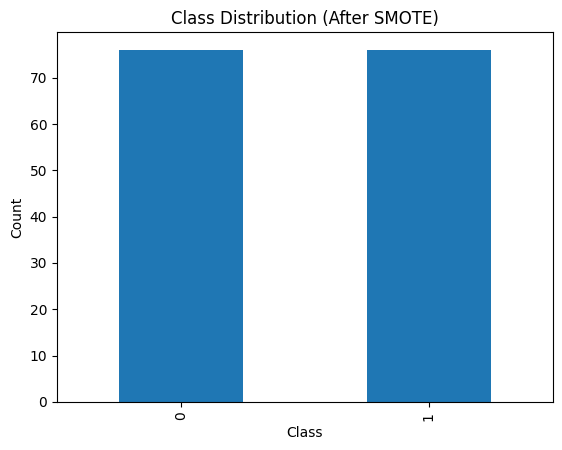

In [28]:
plt.figure()
y_train_res.value_counts().plot(kind="bar")
plt.title("Class Distribution (After SMOTE)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

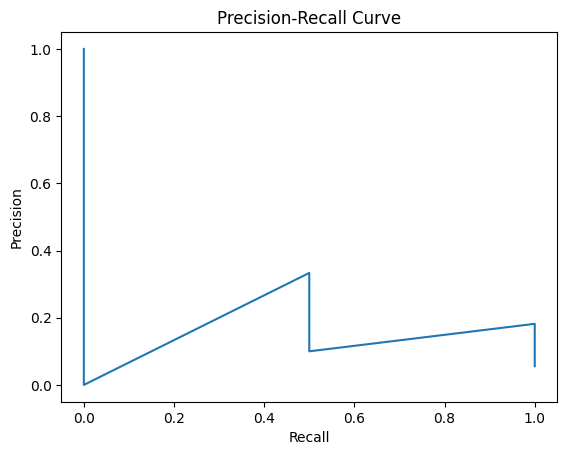

In [29]:
from sklearn.metrics import precision_recall_curve

# probabilities from model trained AFTER SMOTE
y_scores = rf2.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()